<a href="https://colab.research.google.com/github/ginasoft/vision-computacional/blob/main/Clase06_Desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Habilita el eje Z (profundidad)

In [4]:
imagen_bgr = cv2.imread("circulo.jpg")
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

# Muestreo espacial: nos quedamos con 1 pixel cada d (resolucion espacial)
d = 6
imagen_muestreada = imagen_rgb[::d, ::d]
alto, ancho, _ = imagen_muestreada.shape

colores = imagen_muestreada / 255.0  # Normalizamos a [0,1] para facecolors

In [5]:
# Separamos canales (la imagen muestreada esta en RGB)
R = imagen_muestreada[:, :, 0].astype(int)
G = imagen_muestreada[:, :, 1].astype(int)
B = imagen_muestreada[:, :, 2].astype(int)

# Parte A: pixeles predominantemente VERDES
# (canal G mas alto que R y que B con cierto margen)
mascara_A = (G > R + 30) & (G > B + 30)

# Parte B: el resto (mascara inversa)
mascara_B = ~mascara_A

In [6]:
x, y = np.meshgrid(np.arange(ancho), np.arange(alto))
z = np.zeros_like(x)  # Imagen plana en el origen Z=0
w = np.ones_like(x)   # Coordenada homogénea

# [x, y, z, 1]
puntos = np.vstack([x.flatten(), y.flatten(), z.flatten(), w.flatten()]).astype(float)

In [7]:
def matriz_rotacion_Y(grados):
    t = np.deg2rad(grados)
    return np.array([
        [ np.cos(t), 0, np.sin(t), 0],
        [ 0,         1, 0,         0],
        [-np.sin(t), 0, np.cos(t), 0],
        [ 0,         0, 0,         1]
    ])

def matriz_traslacion(tx, ty, tz):
    return np.array([
        [1, 0, 0, tx],
        [0, 1, 0, ty],
        [0, 0, 1, tz],
        [0, 0, 0, 1]
    ], dtype=float)

def matriz_perspectiva(pz):
    # Coeficiente pz en la ultima fila (pptx pag. 14)
    return np.array([
        [1, 0, 0,  0],
        [0, 1, 0,  0],
        [0, 0, 1,  0],
        [0, 0, pz, 1]
    ], dtype=float)

In [8]:
pz = 0.0015

# Parte A: rotacion +45 en Y + traslacion en Z que la ACERCA (tz positivo)
H_A = matriz_perspectiva(pz) @ matriz_traslacion(0, 0, 80) @ matriz_rotacion_Y(45)

In [9]:
# Parte B: rotacion inversa (-45) en Y + traslacion en Z que la ALEJA (tz negativo)
H_B = matriz_perspectiva(pz) @ matriz_traslacion(0, 0, -250) @ matriz_rotacion_Y(-45)

In [10]:
def transformar_y_normalizar(H, puntos):
    p = H @ puntos
    # Normalizacion homogenea: dividir X, Y, Z por la coordenada w (fila 4)
    p = p / p[3, :]
    return p

puntos_A = transformar_y_normalizar(H_A, puntos)
puntos_B = transformar_y_normalizar(H_B, puntos)

In [11]:
def extraer_coords(p):
    xn = p[0, :].reshape(alto, ancho)
    yn = p[1, :].reshape(alto, ancho)
    zn = p[2, :].reshape(alto, ancho)
    return xn, yn, zn

xA, yA, zA = extraer_coords(puntos_A)
xB, yB, zB = extraer_coords(puntos_B)

# Para graficar solo los pixeles de cada parte, ocultamos el resto con NaN
def aplicar_mascara(xn, yn, zn, mascara):
    xm = np.where(mascara, xn, np.nan)
    ym = np.where(mascara, yn, np.nan)
    zm = np.where(mascara, zn, np.nan)
    return xm, ym, zm

xA, yA, zA = aplicar_mascara(xA, yA, zA, mascara_A)
xB, yB, zB = aplicar_mascara(xB, yB, zB, mascara_B)

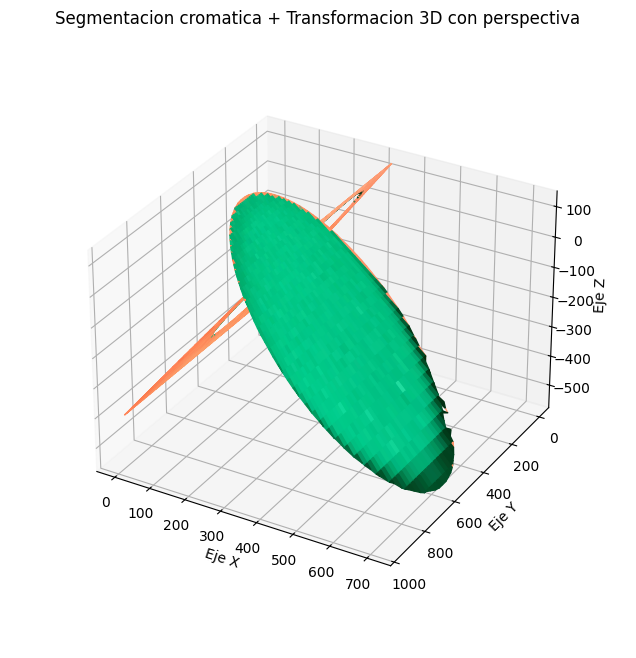

In [12]:
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

# Parte A (verde) en su posicion cercana
ax.plot_surface(xA, yA, zA, facecolors=colores, shade=False)

# Parte B (resto) en su posicion lejana
ax.plot_surface(xB, yB, zB, facecolors=colores, shade=False)

ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Eje Z')
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Segmentacion cromatica + Transformacion 3D con perspectiva")
ax.invert_yaxis()
plt.show()